In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datajoint as dj
import os
import numpy as np
import statistics as stat

dj.config['database.host'] = "arseny-lab.cmte3q4ziyvy.il-central-1.rds.amazonaws.com"
dj.config['database.user'] = ""
dj.config['database.password'] = ""

conn = dj.conn()


[2025-07-22 00:47:15,697][INFO]: Connecting talch012@arseny-lab.cmte3q4ziyvy.il-central-1.rds.amazonaws.com:3306
[2025-07-22 00:47:16,457][INFO]: Connected talch012@arseny-lab.cmte3q4ziyvy.il-central-1.rds.amazonaws.com:3306


In [2]:
# pure random trials [-10,20]
img= dj.schema('talch012_imgt')
img= dj.VirtualModule('IMGt', 'talch012_imgt')
lickiti= dj.schema('talch012_lickiti')
lickiti= dj.VirtualModule ('LICKITI', 'talch012_lickiti')
exp= dj.schema('talch012_expt')
exp= dj.VirtualModule ('EXPt', 'talch012_expt')


In [3]:
exp = dj.VirtualModule("EXPt", "talch012_expt", create_tables=True)
lab = dj.VirtualModule("LABt", "talch012_labt", create_tables=True)
schema_module = dj.VirtualModule("schema_module", "talch012_EPHYS_TEST", create_tables=True)


In [4]:
spikes_time_fetch=schema_module.TrialSpikes

In [5]:
spikes_time_fetch()

subject_id institution 6 digit animal ID,session session number,electrode_group shank number,unit,trial,"spike_times (s) spike times for each trial, relative to the beginning of the trial"""
101104,1,1,0,1,=BLOB=
101104,1,1,1,1,=BLOB=
101104,1,1,2,1,=BLOB=
101104,1,1,3,1,=BLOB=
101104,1,1,4,1,=BLOB=
101104,1,1,5,1,=BLOB=
101104,1,1,6,1,=BLOB=
101104,1,1,7,1,=BLOB=
101104,1,1,8,1,=BLOB=
101104,1,1,9,1,=BLOB=


In [6]:
spike_times=spikes_time_fetch.fetch()

In [33]:
spike_times[100]

(101104, 1, 1, 0, 101, list([0.03186666666666667, 0.08556666666666667, 0.11376666666666667, 0.3851333333333333, 0.6558666666666667, 0.7703, 0.8495333333333334, 0.9047, 0.9109333333333334, 1.0052, 1.0107333333333333, 1.1171333333333333, 1.2367, 1.3413666666666666, 1.4526333333333334, 2.016966666666667, 2.0416666666666665, 2.0728, 2.082, 2.0845, 2.2689333333333335, 2.278566666666667, 2.3101333333333334, 2.321266666666667, 2.4009666666666667, 2.7267, 2.8128, 2.8370333333333333, 2.8404333333333334, 2.845666666666667, 2.852866666666667, 2.963033333333333, 2.9672, 3.0064, 3.4638666666666666, 3.648, 3.707333333333333, 3.7219333333333333, 3.903033333333333, 4.0271333333333335, 4.062633333333333, 4.0841666666666665, 4.1035, 4.3009, 4.322233333333333, 4.389433333333334, 4.566466666666667, 4.6111, 4.802033333333333, 4.833933333333333, 4.9575, 4.961133333333334, 5.027966666666667, 5.1788, 5.1887, 5.421566666666667, 5.4265, 5.440666666666667, 5.4572666666666665, 5.476333333333334, 5.5927, 5.7428, 5

In [67]:
len(spike_times['spike_times'][i])

163

In [71]:
for i in range(len(spike_times['spike_times'])):
    try:
        spikes = spike_times['spike_times'][i]
        if len(spikes) < 1:
            print("Subject ID: {}, Session: {}, Unit: {}, Number of Spikes: {}".format(
                spike_times['subject_id'][i], spike_times['session'][i], spike_times['unit'][i], 0))
    except TypeError:
        print("Subject ID: {}, Session: {}, Unit: {}, Number of Spikes: 0".format(
            spike_times['subject_id'][i], spike_times['session'][i], spike_times['unit'][i]))


Subject ID: 101104, Session: 1, Unit: 0, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 5, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 6, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Session: 1, Unit: 8, Number of Spikes: 0
Subject ID: 101104, Sess

In [53]:
import numpy as np

# Get unique units and subjects
units = np.unique(spike_times['unit'])
subjects = np.unique(spike_times['subject_id'])
all_spikes = {}
bin_size=0.1
all_spike_rates={}
all_spike_data={}
# Iterate over subjects, units, and sessions
for subject_id in subjects:
    for session in np.unique(spike_times['session']):
        for unit in units:
            # Filter the data for the current subject, unit, and session

            trials_subset = spike_times[
                (spike_times['subject_id'] == subject_id) & 
                (spike_times['session'] == session) & 
                (spike_times['unit'] == unit)
            ]
            
            # Now loop over trials within the filtered data
            for trial in trials_subset['trial']:
                # Get spike times for the current trial
                # spike_in_trial=(trials_subset[trials_subset['trial'] == trial]['spike_times'])

                trial_data = trials_subset[trials_subset['trial'] == trial]
                if len(trial_data) == 0:
                    continue

                spike_in_trial = trial_data['spike_times']


                trial_times = (exp.SessionTrial10 & 
                            f'subject_id="{subject_id}"' & 
                            f'session={session}' & 
                            f'trial={trial}').fetch()
                # trial_times=trial_times['start_time']
                start_time = float(trial_times['start_time'][0])  # assuming fetch() returns a 1-row result

                # spike_times_to_conc=start_time+spike_in_trial
                spike_times_to_conc = np.array([np.array(trial1) + start_time for trial1 in spike_in_trial])

            # Skip if no spikes collected
            if len(spike_times_to_conc) == 0 or all(len(s) == 0 for s in spike_times_to_conc):
                continue
                # Process the spike_in_trial data as needed
            
            concatenated_spikes = np.concatenate(spike_times_to_conc)
            # Determine range for binning
            
            start_t = 0
            end_t = np.max(concatenated_spikes)
            bins = np.arange(start_t, end_t + bin_size, bin_size)

            # Bin the spike times
            spike_counts, bin_edges = np.histogram(concatenated_spikes, bins=bins)
            spike_rate_hz = spike_counts / bin_size  # since bin_size is in seconds

            # Store in dictionary
            key = (subject_id, session, unit)
            all_spikes[key] = concatenated_spikes
            spike_counts= spike_counts.astype(np.float64)
            all_spike_rates[key] = spike_rate_hz
            time_bins = bin_edges[:-1] + bin_size / 2
             # Store both in a dict
            key = (subject_id, session, unit)
            all_spike_data[key] = {
                'spike_counts': spike_counts,
                'spike_rate_hz': spike_rate_hz,
                'bin_edges': bin_edges[:-1],  # optional: useful for plotting time axis
            }
            


TypeError: object of type 'numpy.float64' has no len()

In [102]:
import numpy as np

bin_size = 0.1  # 100 ms bins

units = np.unique(spike_times['unit'])
subjects = np.unique(spike_times['subject_id'])
all_spike_data = {}

# Loop over units, subjects, and sessions
for subject_id in subjects:
    for session in np.unique(spike_times['session']):
        for unit in units:

            # Filter rows for current subject, session, and unit
            trials_subset = spike_times[
                (spike_times['subject_id'] == subject_id) &
                (spike_times['session'] == session) &
                (spike_times['unit'] == unit)
            ]

            if len(trials_subset) == 0:
                continue

            all_trial_spikes = []
            trial_start_times = []

            # Loop over sorted trials
            sorted_trials = np.sort(np.unique(trials_subset['trial']))

            for trial in sorted_trials:
                trial_data = trials_subset[trials_subset['trial'] == trial]
                if len(trial_data) == 0:
                    continue

                spike_in_trial = trial_data['spike_times']

                trial_times = (exp.SessionTrial10 & 
                            f'subject_id="{subject_id}"' & 
                            f'session={session}' & 
                            f'trial={trial}').fetch1()

                start_time = float(trial_times['start_time'])
                trial_start_times.append(start_time)

                for trial1 in spike_in_trial:
                    if isinstance(trial1, list) and len(trial1) > 0:
                        adjusted_spikes = np.array(trial1) + start_time
                        all_trial_spikes.append(adjusted_spikes)

            if len(all_trial_spikes) == 0:
                continue

            # Concatenate spikes across all trials
            concatenated_spikes = np.concatenate(all_trial_spikes)
            max_time = np.max(concatenated_spikes)
            n_bins = int(np.ceil(max_time / bin_size))

            # Compute bin indices for each spike
            bin_indices = np.floor(concatenated_spikes / bin_size).astype(int)

            # Count spikes per bin using bincount
            spike_counts = np.bincount(bin_indices, minlength=n_bins)
            spike_rate_hz = spike_counts / bin_size
            time_line = np.arange(n_bins) * bin_size + bin_size / 2

            # Compute start_frames by binning trial start times
            start_frames = np.floor(np.array(trial_start_times) / bin_size).astype(int)

            # Store results
            key = (subject_id, session, unit)
            all_spike_data[key] = {
                'spike_counts': spike_counts,
                'spike_rate_hz': spike_rate_hz,
                'time_line': time_line,
                'start_frames': start_frames,
                'bin_edges': time_line  # midpoints
            }


[2025-07-25 18:54:23,426][WARNING]: MySQL server has gone away. Reconnecting to the server.


KeyboardInterrupt: 

In [108]:
#works
import numpy as np

bin_size = 0.1  # 100 ms bins

units = np.unique(spike_times['unit'])
subjects = np.unique(spike_times['subject_id'])
all_spike_data = {}

# Loop over units, subjects, and sessions
for subject_id in subjects:
    for session in np.unique(spike_times['session']):
        for unit in units:

            # Filter rows for current subject, session, and unit
            trials_subset = spike_times[
                (spike_times['subject_id'] == subject_id) &
                (spike_times['session'] == session) &
                (spike_times['unit'] == unit)
            ]

            if len(trials_subset) == 0:
                continue

            all_trial_spikes = []
            trial_start_times = []

            # Loop over trials in sorted order
            sorted_trials = np.sort(np.unique(trials_subset['trial']))

            for trial in sorted_trials:
                trial_data = trials_subset[trials_subset['trial'] == trial]
                if len(trial_data) == 0:
                    continue

                spike_in_trial = trial_data['spike_times']

                trial_times = (exp.SessionTrial10 & 
                            f'subject_id="{subject_id}"' & 
                            f'session={session}' & 
                            f'trial={trial}').fetch1()

                start_time = float(trial_times['start_time'])
                trial_start_times.append(start_time)

                for trial1 in spike_in_trial:
                    if isinstance(trial1, list) and len(trial1) > 0:
                        adjusted_spikes = np.array(trial1) + start_time
                        all_trial_spikes.append(adjusted_spikes)

            if len(all_trial_spikes) == 0:
                continue

            # Concatenate all spikes across trials
            concatenated_spikes = np.concatenate(all_trial_spikes)
            max_time = np.max(concatenated_spikes)

            # Compute bin edges and histogram
            time_bins = np.arange(0, max_time + bin_size, bin_size)
            spike_counts, bin_edges = np.histogram(concatenated_spikes, bins=time_bins)
            spike_rate_hz = spike_counts / bin_size
            time_line = bin_edges[:-1] + bin_size / 2

            # Compute start_frames for each trial based on bin_edges
            start_frames = np.digitize(trial_start_times, bin_edges) - 1  # subtract 1 to get 0-based bin index

            # Store results
            key = (subject_id, session, unit)
            all_spike_data[key] = {
                'spike_counts': spike_counts,
                'spike_rate_hz': spike_rate_hz,
                'time_line': time_line,
                'start_frames': np.array(start_frames),
                'bin_edges': bin_edges[:-1]
            }


[2025-07-25 18:56:37,104][WARNING]: MySQL server has gone away. Reconnecting to the server.


In [109]:
all_spike_data

{(101104, 1, 0): {'spike_counts': array([2, 1, 1, ..., 1, 0, 1], dtype=int64),
  'spike_rate_hz': array([20., 10., 10., ..., 10.,  0., 10.]),
  'time_line': array([5.00000e-02, 1.50000e-01, 2.50000e-01, ..., 2.52395e+03,
         2.52405e+03, 2.52415e+03]),
  'start_frames': array([    0,   128,   246,   364,   482,   601,   718,   836,   954,
          1010,  1128,  1246,  1364,  1482,  1600,  1718,  1836,  1954,
          2072,  2190,  2308,  2426,  2544,  2662,  2780,  2899,  3017,
          3135,  3253,  3371,  3489,  3607,  3673,  3725,  3829,  3882,
          3935,  4013,  4110,  4204,  4261,  4324,  4398,  4859,  5819,
          6816,  6934,  7168,  8096,  9002,  9799, 10329, 12041, 12184,
         12249, 12324, 12447, 12957, 13060, 13122, 13198, 13277, 13365,
         13425, 13505, 13557, 13645, 13698, 13760, 13866, 13995, 14086,
         14164, 14257, 14317, 14372, 14479, 14546, 14618, 14670, 14808,
         14924, 14983, 15099, 15170, 15272, 15390, 15505, 15651, 15727,
      

In [98]:
total_spikes = sum(np.sum(data['spike_counts']) for data in all_spike_data.values())
print(f"✅ Total spikes in all_spike_data: {int(total_spikes)}")


✅ Total spikes in all_spike_data: 39651


In [99]:
spike_times_3 = spike_times['spike_times'][spike_times['unit'] == 1]

In [111]:
# Flatten the lists and count
total_spikes_unit_3 = sum(len(trial) for trial in spike_times_3 if isinstance(trial, list))
print(f"Total spikes for unit 3: {total_spikes_unit_3}")


Total spikes for unit 3: 4486


In [119]:
import random
import numpy as np

# Total spike count across all units
total_spikes = sum(np.sum(data['spike_counts']) for data in all_spike_data.values())
print(f"✅ Total spikes in all_spike_data: {int(total_spikes)}")

# Example unit (first or random)
if len(all_spike_data) == 0:
    print("No data in all_spike_data.")
else:
    unit1=10
    # Choose example unit
    example_key = random.choice(list(all_spike_data.keys()))  # or use list(...)[0] for first unit
    example_data = all_spike_data[subject_id, session, unit1]  # unpack the key

    subject_id, session, unit = example_key
    spike_count = int(np.sum(example_data['spike_counts']))
    print(f"\n🔍 Example unit:")
    print(f"Subject: {subject_id}, Session: {session}, Unit: {unit1}")
    print(f"Total spikes: {spike_count}")
    print(f"Start frames: {example_data['start_frames']}")
    print(f"Spike rate time series (Hz): {example_data['spike_rate_hz'][:10]} ...")
    print(f"Time bins (s): {example_data['time_line'][:10]} ...")


✅ Total spikes in all_spike_data: 5923539

🔍 Example unit:
Subject: 101104, Session: 1, Unit: 10
Total spikes: 8198
Start frames: [    0   128   246   364   482   601   718   836   954  1010  1128  1246
  1364  1482  1600  1718  1836  1954  2072  2190  2308  2426  2544  2662
  2780  2899  3017  3135  3253  3371  3489  3607  3673  3725  3829  3882
  3935  4013  4110  4204  4261  4324  4398  4859  5819  6816  6934  7168
  8096  9002  9799 10329 12041 12184 12249 12324 12447 12957 13060 13122
 13198 13277 13365 13425 13505 13557 13645 13698 13760 13866 13995 14086
 14164 14257 14317 14372 14479 14546 14618 14670 14808 14924 14983 15099
 15170 15272 15390 15505 15651 15727 15781 15860 15978 16096 16159 16222
 16309 16443 16525 16643 16762 16880 16999 17117 17255 17374 17451 17509
 17616 17725 17840 17916 17979 18097 18157 18275 18394 18512 18635 18754
 18822 18886 18944 19010 19093 19211 19290 19408 19527 19592 19711 19829
 19960 20079 20153 20271 20390 20509 20572 20691 20809 20866 20927 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select a unit to plot
subject_id, session, unit = 101104, 1, 1
data = all_spike_data[(subject_id, session, unit)]

# Get bin information
bin_edges = data['bin_edges']
bin_size = 0.1  # seconds
bin_centers = bin_edges + bin_size / 2

# Spike rate (in Hz)
spike_rate_hz = data['spike_rate_hz']

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(bin_centers, spike_rate_hz, color='black', lw=1.5, label='Spike Rate')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Firing Rate (spikes/s)', fontsize=12)
plt.title(f'Firing Rate over Time\nSubject {subject_id}, Session {session}, Unit {unit}', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()


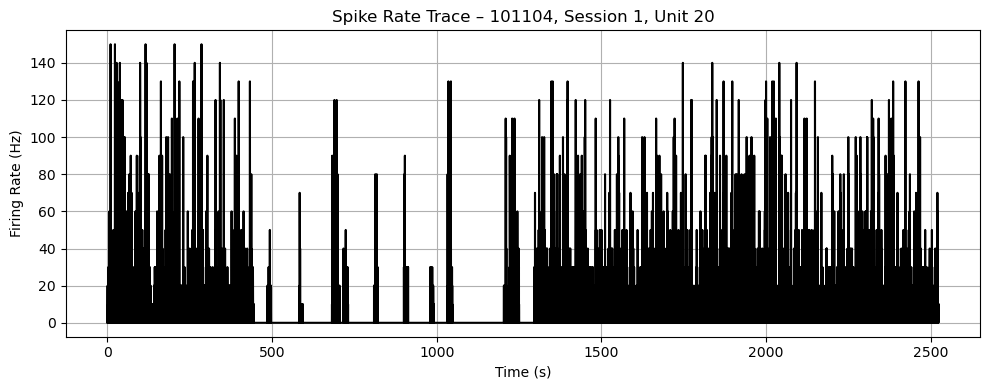

In [129]:
import matplotlib.pyplot as plt
import numpy as np

subject_id, session, unit = 101104, 1, 20
data = all_spike_data[(subject_id, session, unit)]

bin_edges = data['bin_edges']        # left edges of bins
bin_size = 0.1
bin_centers = bin_edges + bin_size / 2  

spike_rate_hz = data['spike_rate_hz']

plt.figure(figsize=(10, 4))
plt.plot(bin_centers, spike_rate_hz, label='Spike Rate', color='black')
plt.xlabel('Time (s)')
plt.ylabel('Firing Rate (Hz)')
plt.title(f'Spike Rate Trace – {subject_id}, Session {session}, Unit {unit}')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
trial_times

array([(101104, 1, 19, 1052, Decimal('207.2500'))],
      dtype=[('subject_id', '<i8'), ('session', '<i8'), ('trial', '<i8'), ('trial_uid', '<i8'), ('start_time', 'O')])

In [ ]:
trial_times=(exp.SessionTrial10 & 'subject_id=101104').fetch()